# Diffusion Maps, Lafon2006
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [기하학적 딥러닝]

### About this doc 

`-` reference

Lafon, S., & Lee, A. B. (2006). Diffusion maps and coarse-graining: A unified framework for dimensionality reduction, graph partitioning, and data set parameterization. IEEE transactions on pattern analysis and machine intelligence, 28(9), 1393-1403.

Nadler, B., Lafon, S., Coifman, R. R., & Kevrekidis, I. G. (2006). Diffusion maps, spectral clustering and reaction coordinates of dynamical systems. Applied and Computational Harmonic Analysis, 21(1), 113-127.

Coifman, R. R., & Lafon, S. (2006). Diffusion maps. Applied and computational harmonic analysis, 21(1), 5-30.

### Notations

`-` $\Omega=\{x_1,x_2,\dots,x_n\}=$ a data set of points

`-` $w(x,y)=$ weight function

`-` $G=(\Omega,W)$ 

`-` $p_1(x,y)=\frac{w(x,y)}{\sum_{z \in \Omega}w(x,z)}=\frac{w(x,y)}{d(x)}$probability of going from point $x$ to $y$ in one step 

`-` $d(x)=\sum_{z\in \Omega}w(x,z)=$ out-degree 

`-` $\phi_0(x)=\frac{d(x)}{\sum_{z\in \Omega}d(z)}$

`-` $p_t(x,\cdot)$

### Basic Thm

`-` (에르고드성) 그래프가 연결되어 있다면 아래가 성립한다. 

$$\lim_{t \to \infty }p_t(x,y)=\phi_0(y)$$

### Point 

### 구현

#### import

In [1]:
import pybase as my
import matplotlib.cm as cm
import math
import numpy as np
import pandas as pd
import rpy2 
import rpy2.robjects as ro 
import matplotlib.pyplot as plt
%load_ext rpy2.ipython

#### data

In [2]:
np.random.seed(777)
pi=math.pi
n=59
ang=np.linspace(-pi,pi-2*pi/n,n)
V=np.arange(n)+1
r=1
vx=r*np.cos(ang)
vy=r*np.sin(ang)
f1=vx*0
f2=vx*0
f2[vy<0]=3+np.random.normal(size=sum(vy<0),scale=0.1)
f2[vy>0]= -3+np.random.normal(size=sum(vy>0),scale=0.1)

#### graph signal 

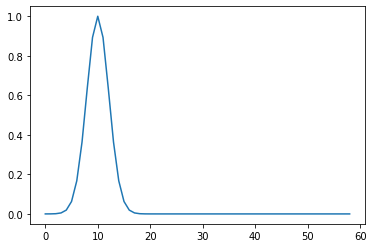

In [3]:
# Edg setting
Simga=my.l2distance(np.matrix([vx,vy]).T)
W=np.exp(-my.l2distance(np.matrix([vx,vy]).T)/(2*0.05))
plt.plot(W[10,:].T)
# color
col=list(np.array(cm.rainbow((ang+pi)/2/pi)))

In [4]:
W.round(3).sum(axis=0)[0]

5.294

#### transition matrix

In [5]:
P=W/W.round(3).sum(axis=0)[0]

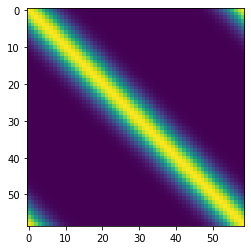

In [6]:
plt.imshow(P@P@P@P)

#### diffusion distance

In [7]:
P4=P@P@P@P

In [17]:
diffusion_distance=my.l2distance(P4)

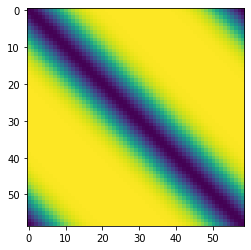

In [18]:
plt.imshow(diffusion_distance)